In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pymoo.algorithms.moo.moead import MOEAD
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.core.callback import Callback
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from meamt_core import generate_dtlz3_front_random
from pymoo.indicators.igd_plus import IGDPlus

NOBJ = 5
K = 10
NDIM = NOBJ + K - 1
NGEN = 600

# ==========================================
# 3. Callback Customizado Atualizado
# ==========================================
class MetricCallback(Callback):
    def __init__(self, ref_point, pf_real) -> None:
        super().__init__()
        
        # 2. Instancia os calculadores de métrica do pymoo
        # O pymoo exige que o ref_point seja um array numpy
        self.ind_hv = HV(ref_point=np.array(ref_point))
        self.ind_igd_plus = IGDPlus(pf_real)
        
        self.n_gens = []
        self.hv_history = []
        self.igd_plus_history = []

    def notify(self, algorithm):
        self.n_gens.append(algorithm.n_gen)
        
        F = algorithm.opt.get("F")
        
        if F is not None and len(F) > 0:
            
            # Filtro do DTLZ1 continua sendo uma boa prática
            F_filtrado = F[(F < 1.1).all(axis=1)]
            
            # 3. O cálculo agora é direto na matriz!
            if len(F_filtrado) > 0:
                hv_atual = self.ind_hv(F_filtrado)
            else:
                hv_atual = 0.0
                
            igd_atual = self.ind_igd_plus(F)
            
        else:
            hv_atual = 0.0
            igd_atual = float('inf') 
            
        self.hv_history.append(hv_atual)
        self.igd_plus_history.append(igd_atual)
# ==========================================
# 4. Configuração e Execução
# ==========================================

# Define o ponto de referência para o cálculo do HV. 
# Para o ZDT1 (objetivos entre 0 e 1), [1.1, 1.1] é um valor comum.
ponto_referencia_hv = [1.1] * NOBJ

# Vetores de referência para o MOEA/D
ref_dirs = get_reference_directions("das-dennis", NOBJ, n_partitions=6)

# Instancia o problema
problem = get_problem("dtlz4", n_var=NDIM, n_obj=NOBJ)

fronteira_pareto_real = generate_dtlz3_front_random(NOBJ, 1000)

algorithm = MOEAD(
    ref_dirs,
    n_neighbors=15,
    prob_neighbor_mating=0.9,
)

# Instancia o callback passando a fronteira real e o ponto de referência
meu_callback = MetricCallback(ref_point=ponto_referencia_hv, pf_real=fronteira_pareto_real)

res = minimize(
    problem,
    algorithm,
    termination=('n_gen', NGEN),
    callback=meu_callback,
    seed=1,
    verbose=False
)

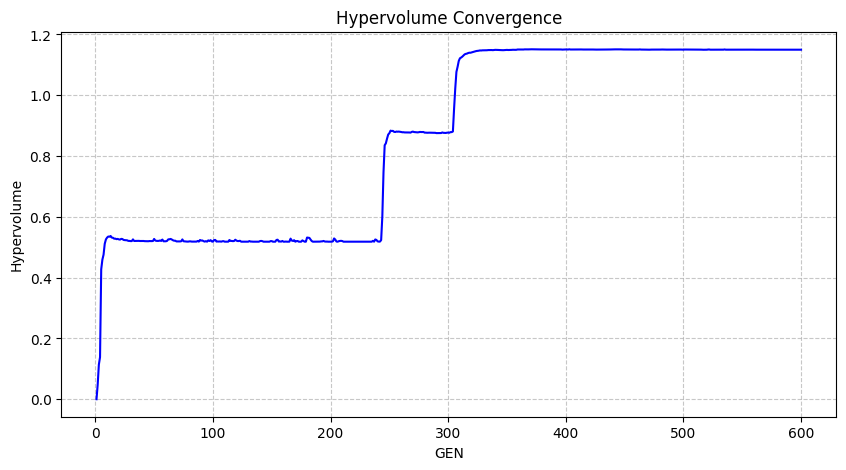

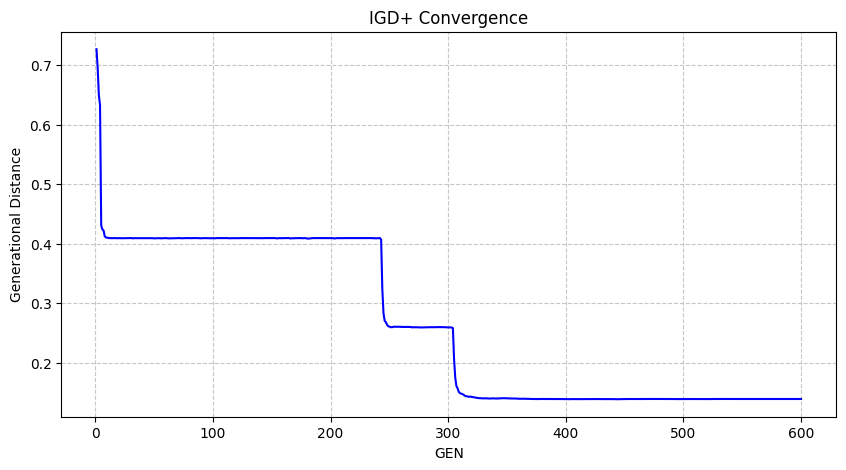

1.149718075106662
0.1393471260795243


In [2]:
# ==========================================
# 5. Geração dos Gráficos
# ==========================================
geracoes = meu_callback.n_gens
hv_valores = meu_callback.hv_history
igd_valores = meu_callback.igd_plus_history

plt.figure(figsize=(10, 5))
plt.plot(geracoes, hv_valores, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)

# IGD+ Graphic
plt.figure(figsize=(10, 5))
plt.plot(geracoes, igd_valores, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print(hv_valores[len(hv_valores)-1])
print(igd_valores[len(igd_valores)-1])